Initial shape: (150, 5)
Missing labels handling: drop_missing_y=False, kept 0 row(s) with missing values in 'species'.
Label column: 'species'
Label handling: factorized categorical/string labels into integer codes.
Number of classes: 3
Categorical feature columns: none
Continuous numeric feature columns: ['sepal_length', 'sepal_width', 'petal_length', 'petal_width']
Binary / indicator feature columns: none
Feature handling: no categorical feature columns to one-hot encode.
Scaling: standardized continuous numeric feature columns using Z-score.
Final feature shape: (150, 4)
Train samples: 120, Test samples: 30
Number of features: 4


[Parallel(n_jobs=-1)]: Using backend ThreadingBackend with 32 concurrent workers.
[Parallel(n_jobs=-1)]: Done 100 out of 100 | elapsed:    0.1s finished
[Parallel(n_jobs=-1)]: Using backend ThreadingBackend with 32 concurrent workers.
[Parallel(n_jobs=-1)]: Done 100 out of 100 | elapsed:    0.0s finished
[Parallel(n_jobs=-1)]: Using backend ThreadingBackend with 32 concurrent workers.
[Parallel(n_jobs=-1)]: Done 100 out of 100 | elapsed:    0.0s finished


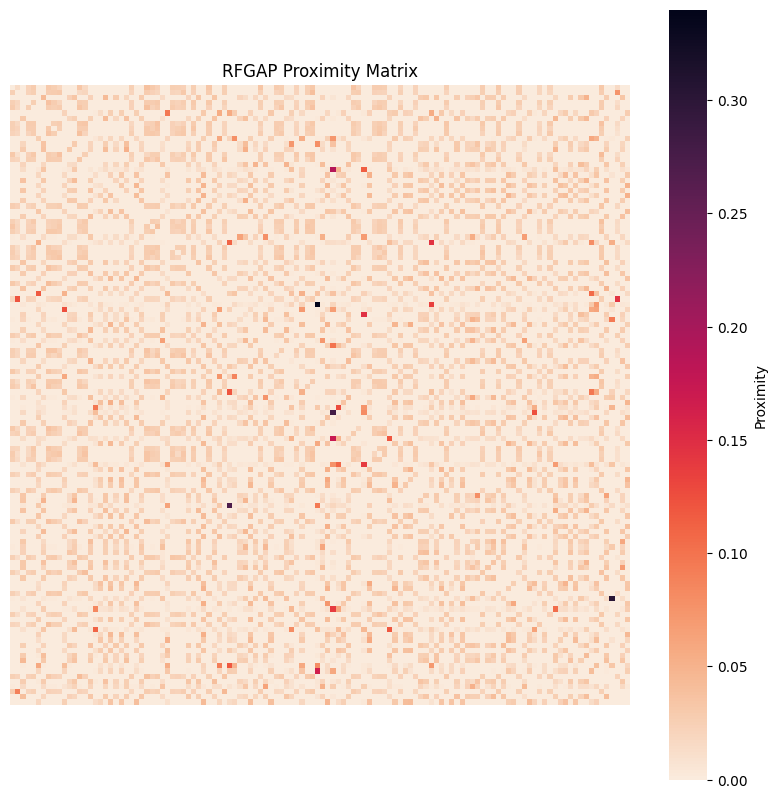

Row sums :
[1.         1.         1.0000001  0.99999994 0.99999994 0.99999994
 1.         1.         1.         1.         0.99999994 1.
 1.         1.         1.         1.0000001  1.         1.0000001
 1.         1.         1.         1.0000001  1.0000001  1.
 1.         1.         1.         1.0000001  1.         1.
 1.0000001  1.         1.         0.99999994 1.         1.
 1.0000001  1.         1.         1.         1.         1.
 1.         1.         0.99999994 1.0000001  1.         1.
 1.         1.         0.99999994 1.         1.         0.99999994
 1.         1.         1.         1.         1.         1.0000001
 1.         1.         1.         1.         1.         1.
 1.         1.         1.         1.         0.99999994 1.0000001
 0.99999994 1.         1.         1.         1.         1.
 1.         1.0000001  1.         1.         1.         1.
 1.         1.         1.         1.         1.         1.
 1.         1.         1.         1.         1.         1.
 1.     

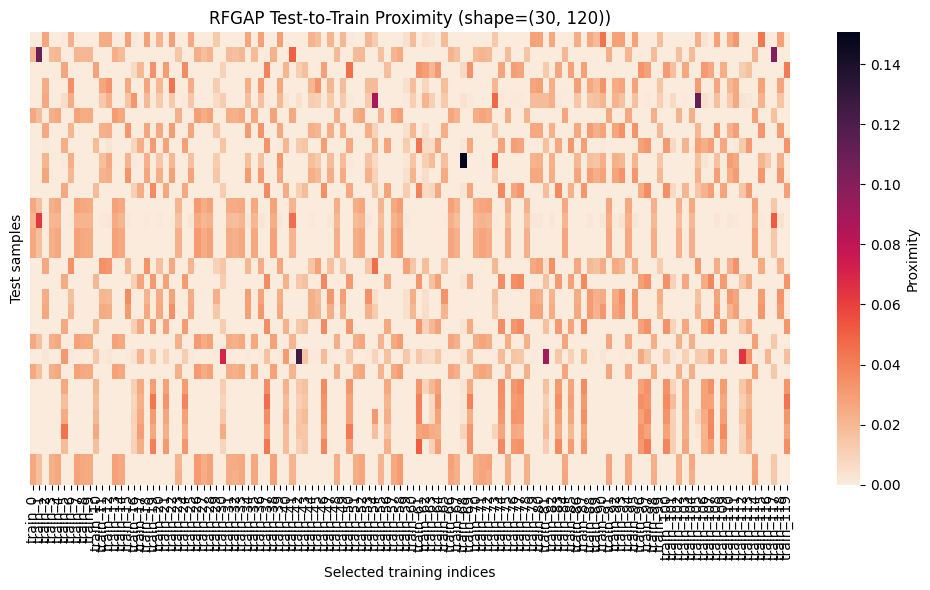


TRAIN
rows: 120
min, max, mean: 0.99999994 1.0000001 1.0
rows ~1 within rtol=1e-05, atol=1e-08: 120/120
All rows sum approximately to 1.

TEST / OOS
rows: 30
min, max, mean: 0.99999976 1.0 0.9999999
rows ~1 within rtol=1e-05, atol=1e-08: 30/30
All rows sum approximately to 1.


In [3]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

from sklearn.model_selection import train_test_split
from dataset import dataprep

from forestkernel.reference_rfgap import RFGAP


seed = 42

weight_scheme = "rfgap"   # old name for new "gap"
forest_type = "rf"

force_symmetric = False
adjust_diagonal = False

max_samples = None
oob_score = True
bootstrap = True
n_estimators = 100
verbose = 1
n_jobs = -1

test_size = 0.2

data = pd.read_csv("/NOBACKUP/aumona/projects/RF-GAP-Python/data/iris.csv")
x, y = dataprep(data)

x_train, x_test, y_train, y_test = train_test_split(
    x,
    y,
    test_size=test_size,
    random_state=seed,
)

print(f"Train samples: {x_train.shape[0]}, Test samples: {x_test.shape[0]}")
print(f"Number of features: {x_train.shape[1]}")


rf_old = RFGAP(
    prediction_type="classification",
    y=None,
    prox_method=weight_scheme,
    matrix_type="sparse",
    non_zero_diagonal=adjust_diagonal,
    symm_mode=None if not force_symmetric else "arithmetic",
    max_normalize=False,
    model_type=forest_type,
    random_state=seed,
    max_samples=max_samples,
    n_jobs=n_jobs,
    verbose=verbose,
    oob_score=oob_score,
    bootstrap=bootstrap,
    n_estimators=n_estimators,
)

rf_old.fit(x_train, y_train)

prox = rf_old.get_proximities()
test_prox = rf_old.prox_extend(x_test)


# ---------------------------------------------------------------------
# Train proximity: exact same display/check format
# ---------------------------------------------------------------------
prox_mat = prox.toarray()

mask = np.eye(prox_mat.shape[0], dtype=bool)
mask = None

fig, ax = plt.subplots(figsize=(10, 10))
sns.heatmap(
    prox_mat,
    ax=ax,
    cmap="rocket_r",
    vmin=0,
    vmax=prox_mat.max(),
    mask=mask,
    xticklabels=False,
    yticklabels=False,
    square=True,
    cbar_kws={"label": "Proximity"},
)
ax.set_title(f"{weight_scheme.upper()} Proximity Matrix")
plt.show()

row_sums = prox_mat.sum(axis=1)
print("Row sums :")
print(row_sums)

col_sums = prox_mat.sum(axis=0)
print("Column sums :")
print(col_sums)

diag = prox.diagonal()
print("Diagonal values:")
print(diag)

off_diag_max = prox_mat - np.diag(diag)
print("Max off-diagonal value:")
print(off_diag_max.max())


# ---------------------------------------------------------------------
# Test/OOS proximity: exact same display/check style
# ---------------------------------------------------------------------
selected_train_indices = np.arange(x_train.shape[0])
test_prox = test_prox.toarray()

fig, ax = plt.subplots(figsize=(10, 6))
sns.heatmap(
    test_prox,
    ax=ax,
    cmap="rocket_r",
    vmin=0,
    vmax=test_prox.max(),
    xticklabels=[f"train_{i}" for i in selected_train_indices],
    yticklabels=False,
    cbar_kws={"label": "Proximity"},
)
ax.set_xlabel("Selected training indices")
ax.set_ylabel("Test samples")
ax.set_title(f"{weight_scheme.upper()} Test-to-Train Proximity (shape={test_prox.shape})")
plt.tight_layout()
plt.show()


# ---------------------------------------------------------------------
# Row-sum checks for train and test
# ---------------------------------------------------------------------
for name, M in [("TRAIN", prox_mat), ("TEST / OOS", test_prox)]:
    row_sums = np.sum(M, axis=1)

    print(f"\n{name}")
    print("rows:", row_sums.shape[0])
    print("min, max, mean:", row_sums.min(), row_sums.max(), row_sums.mean())

    tol_r, tol_a = 1e-5, 1e-8
    close_mask = np.isclose(row_sums, 1.0, rtol=tol_r, atol=tol_a)
    print(
        f"rows ~1 within rtol={tol_r}, atol={tol_a}: "
        f"{np.count_nonzero(close_mask)}/{len(row_sums)}"
    )

    bad_idx = np.where(~close_mask)[0]
    if bad_idx.size:
        print("Example rows not summing to ~1 (index, sum):")
        for i in bad_idx[:10]:
            print(i, row_sums[i])
    else:
        print("All rows sum approximately to 1.")